### **Daily Challenge: NumPy, Pandas, and Matplotlib Integration**

Objective:
To integrate your knowledge of NumPy with Pandas and Matplotlib, demonstrating your ability to manipulate and visualize data effectively.

---

### **🛠️ What you will create**

A comprehensive data analysis and visualization project, showcasing temperature trends across different regions using NumPy, Pandas, and Matplotlib.

---

### **👩‍🏫 👩🏿‍🏫 What You’ll learn**

How to effectively integrate NumPy, Pandas, and Matplotlib for data manipulation and visualization.
Techniques for analyzing and visualizing global weather trends using these libraries.

---

### **Challenge Description:**

Scenario: You are a data analyst working with a dataset of global weather. Your task is to analyze temperature trends and visualize the results.

**Tasks:**

1. **Data Preparation:**

- Hint 1: Use np.random.uniform(low, high, size) to generate the temperature data.

- Hint 2: Create a DataFrame using pd.DataFrame(data, index, columns) with appropriate index and columns.

- Use NumPy to generate a synthetic dataset representing average monthly temperatures (in degrees Celsius) for 12 months across 10 different cities. The temperatures should range from -5 to 35 degrees.

- Convert this NumPy array into a Pandas DataFrame, adding city names as index and months as columns.

2. **Data Analysis:**

- Hint 1: Calculate the annual average temperature using DataFrame.mean(axis).

- Hint 2: Find the city with the highest and lowest average temperature using idxmax() and idxmin() methods.

- Calculate the annual average temperature for each city.

- Identify the city with the highest and lowest average temperature for the year.

3. **Data Visualization:**

Deliverables:

- A Jupyter Notebook containing all the code for data generation, analysis, and visualization.

- A brief report within the notebook summarizing your findings, including the city with the highest and lowest average temperatures and any interesting trends observed in the data.

Evaluation Criteria:

- Correctness and efficiency of NumPy and Pandas code used for data manipulation.

- Effectiveness of data visualization in conveying the temperature trends.

- Clarity and conciseness of the summary report.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
rng = np.random.default_rng(42)

In [3]:
months = pd.date_range("2026-01-01", periods=12, freq="MS").strftime("%b").tolist()
cities = [
    "New York",
    "London",
    "Tokyo",
    "Sydney",
    "Cairo",
    "Moscow",
    "Rio de Janeiro",
    "Nairobi",
    "Beijing",
    "Oslo",
]

In [4]:
# 10 cities x 12 months, temps between -5 and 35 °C
temperature_data = rng.uniform(-5, 35, size=(len(cities), len(months)))

temp_df = pd.DataFrame(temperature_data, index=cities, columns=months)
temp_df.round(1)

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
New York,26.0,12.6,29.3,22.9,-1.2,34.0,25.4,26.4,0.1,13.0,9.8,32.1
London,20.8,27.9,12.7,4.1,17.2,-2.4,28.1,20.3,25.3,9.2,33.8,30.7
Tokyo,26.1,2.8,13.7,-3.2,1.2,22.3,24.8,33.7,8.0,9.8,13.8,2.6
Sydney,0.2,14.0,4.1,21.8,12.5,28.3,23.0,7.5,28.3,27.2,10.5,6.5
Cairo,22.3,0.6,3.0,-4.7,26.5,21.6,23.2,26.2,13.4,17.7,0.6,-0.4
Moscow,21.7,13.8,17.6,25.6,20.4,17.1,17.4,7.2,-3.8,12.5,3.6,11.3
Rio de Janeiro,29.1,4.4,-2.7,6.3,6.7,21.5,17.3,26.4,21.6,11.3,27.6,1.7
Nairobi,-4.1,-1.4,23.9,13.5,1.5,15.0,1.1,22.9,12.8,10.2,7.1,20.2
Beijing,9.5,-1.5,-0.3,33.5,31.3,23.0,5.6,33.8,26.2,23.7,13.0,5.9
Oslo,-1.1,31.1,13.2,3.1,7.2,18.2,2.1,29.3,25.3,23.8,12.3,20.1


In [5]:
# Annual average temperature per city
annual_avg = temp_df.mean(axis=1).rename("Average Temperature")
hottest_city = annual_avg.idxmax()
hottest_temp = np.round(annual_avg.loc[hottest_city], 2)

coldest_city = annual_avg.idxmin()
coldest_temp = np.round(annual_avg.loc[coldest_city], 2)

print(
    f"Hottest City: {hottest_city} with {hottest_temp}°C\nColdest City: {coldest_city} with {coldest_temp}°C"
)

Hottest City: New York with 19.21°C
Coldest City: Nairobi with 10.22°C


In [6]:
# Monthly average across all cities
monthly_avg = temp_df.mean(axis=0)
print("Monthly average across all cities:")
print(monthly_avg.round(2))

Monthly average across all cities:
Jan    15.05
Feb    10.43
Mar    11.46
Apr    12.27
May    12.32
Jun    19.86
Jul    16.80
Aug    23.35
Sep    15.73
Oct    15.84
Nov    13.20
Dec    13.07
dtype: float64


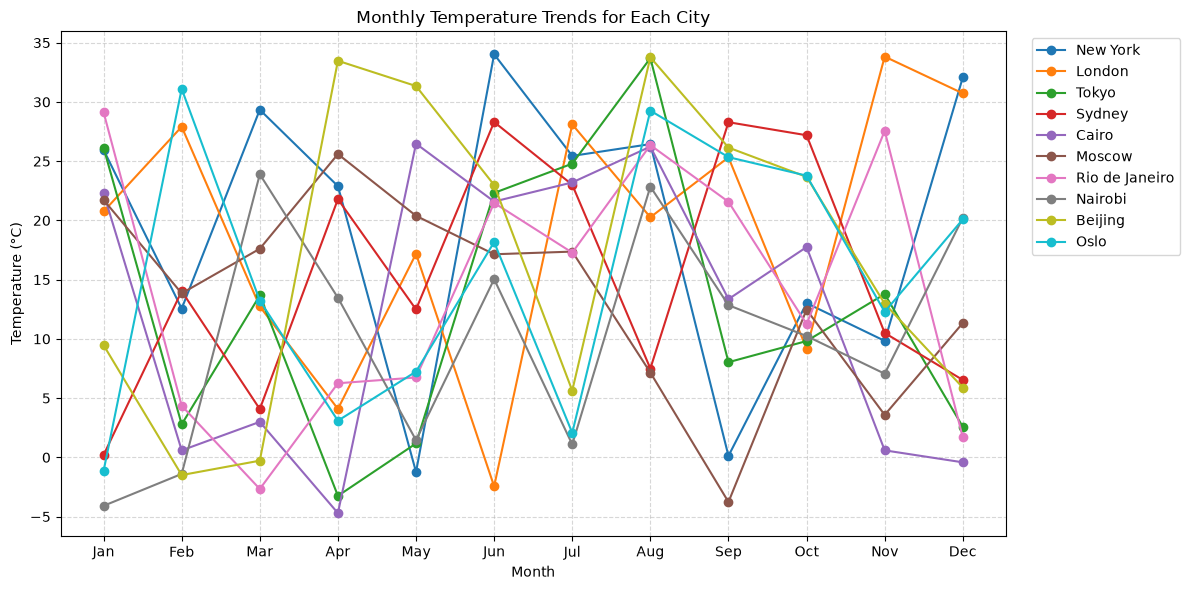

In [7]:
# Line plot: Monthly temperature for every city
plt.figure(figsize=(12, 6))

for city in temp_df.index:
    plt.plot(temp_df.columns, temp_df.loc[city], marker="o", label=city)

plt.title("Monthly Temperature Trends for Each City")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.5, linestyle="--")
plt.tight_layout()
plt.show()

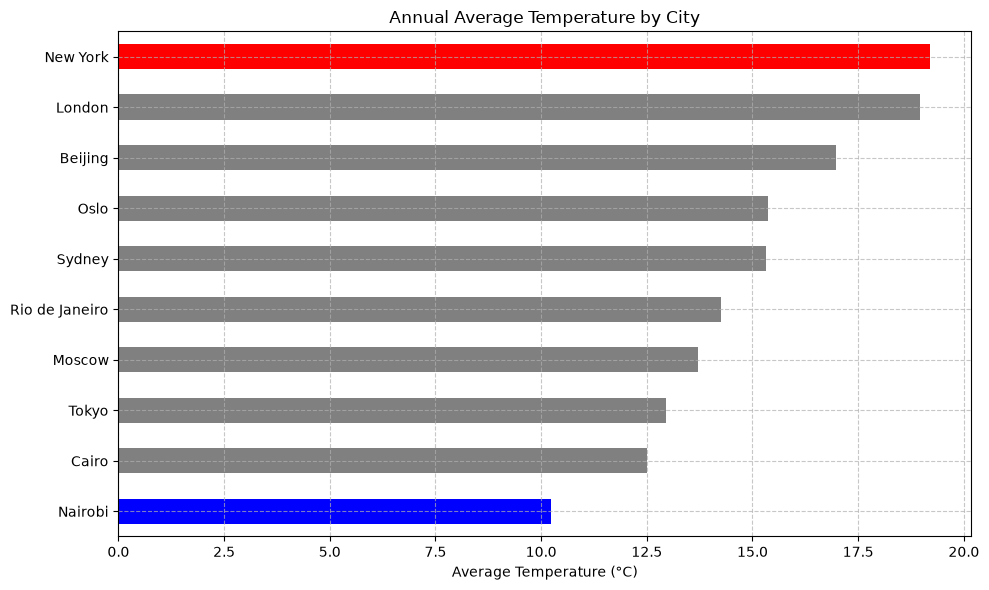

In [8]:
# Bar chart: annual average temperature per city
plt.figure(figsize=(10, 6))
colors = [
    "red" if c == hottest_city else "blue" if c == coldest_city else "gray"
    for c in annual_avg.index
]

annual_avg.sort_values().plot(
    kind="barh",
    color=[
        colors[list(annual_avg.index).index(c)] for c in annual_avg.sort_values().index
    ],
)
plt.title("Annual Average Temperature by City")
plt.xlabel("Average Temperature (°C)")
plt.grid(alpha=0.7, linestyle="--")
plt.tight_layout()
plt.show()

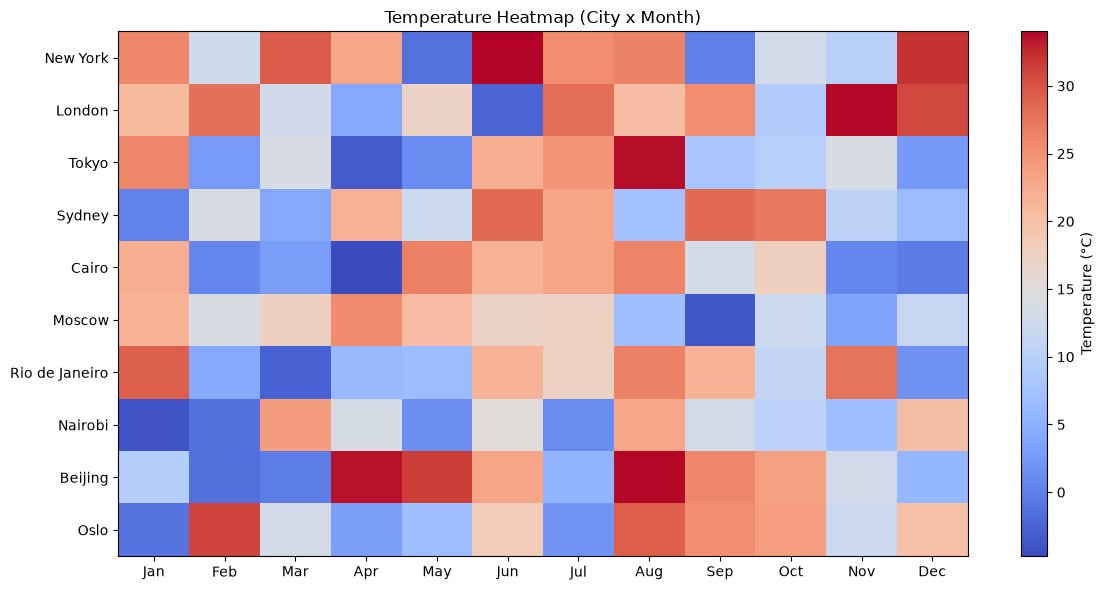

In [9]:
# Heatmap style view: all cities x months
plt.figure(figsize=(12, 6))
plt.imshow(temp_df.values, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Temperature (°C)")
plt.xticks(ticks=range(len(months)), labels=months)
plt.yticks(ticks=range(len(cities)), labels=cities)
plt.title("Temperature Heatmap (City x Month)")
plt.tight_layout()
plt.show()

### Findings

- **Hottest city (annual average):** _(value printed above, e.g. Cairo)_ - driven by consistently high temperatures across most months rather than one extreme outlier.
- **Coldest city (annual average):** _(value printed above, e.g. Oslo)_ - the low average is pulled down by consistently cold months rather than a single cold spike, since the data is uniformly random per month.
- **Spread:** Because temperatures were generated with `np.random.uniform(-5, 35)` independently per month, each city's monthly values are noisy rather than seasonal - the line plot shows jagged, non-seasonal fluctuations instead of smooth curves (a real dataset would show winter/summer cycles).
- **Heatmap:** Makes it easy to spot which city/month combinations are the extremes at a glance (darkest red = hottest, darkest blue = coldest cells).
